# **Fraud Detection** - in Bank Transaction

This project builds an intelligent fraud detection system for banking transactions using a hybrid machine learning approach that combines clustering algorithms to identify suspicious patterns in unlabeled data with supervised models including Random Forest and Deep Neural Networks, delivering accurate real-time fraud prediction capabilities for financial institutions.

## **1. Import Library**
Import semua library yang dibutuhkan untuk analisis, preprocessing, modeling, dan evaluasi

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, KFold

# Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# Machine Learning Models
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# Evaluation Metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score


## **2. Load Data**
Memuat dataset bank transaction dari file CSV dan melakukan explorasi awal untuk memahami struktur data

In [29]:
# Upload file: bank_transactions_data.csv
df = pd.read_csv('data/bank_transactions_data.csv')

## **3. Data Understanding**

In [30]:
print("="*80)
print("DATA OVERVIEW")
print("="*80)
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nData Info:")
print(df.info())
print(f"\nMissing Values:")
print(df.isnull().sum())
print(f"\nStatistical Summary:")
print(df.describe())

DATA OVERVIEW
Shape: (2512, 16)

First 5 rows:
  TransactionID AccountID  TransactionAmount      TransactionDate  \
0      TX000001   AC00128              14.09  2023-04-11 16:29:14   
1      TX000002   AC00455             376.24  2023-06-27 16:44:19   
2      TX000003   AC00019             126.29  2023-07-10 18:16:08   
3      TX000004   AC00070             184.50  2023-05-05 16:32:11   
4      TX000005   AC00411              13.45  2023-10-16 17:51:24   

  TransactionType   Location DeviceID      IP Address MerchantID Channel  \
0           Debit  San Diego  D000380  162.198.218.92       M015     ATM   
1           Debit    Houston  D000051     13.149.61.4       M052     ATM   
2           Debit       Mesa  D000235  215.97.143.157       M009  Online   
3           Debit    Raleigh  D000187  200.13.225.150       M002  Online   
4          Credit    Atlanta  D000308    65.164.3.100       M091  Online   

   CustomerAge CustomerOccupation  TransactionDuration  LoginAttempts  \
0       

## **4. Exploratory Data Analysis (EDA)**
Visualisasi data untuk memahami distribusi dan pola pada fitur-fitur penting seperti:
- Transaction Amount: Distribusi nilai transaksi
- Transaction Type: Perbandingan Debit vs Credit
- Channel: Metode transaksi (Online, ATM, Branch)
- Login Attempts: Indikator potensial fraud (login attempts tinggi)


EXPLORATORY DATA ANALYSIS


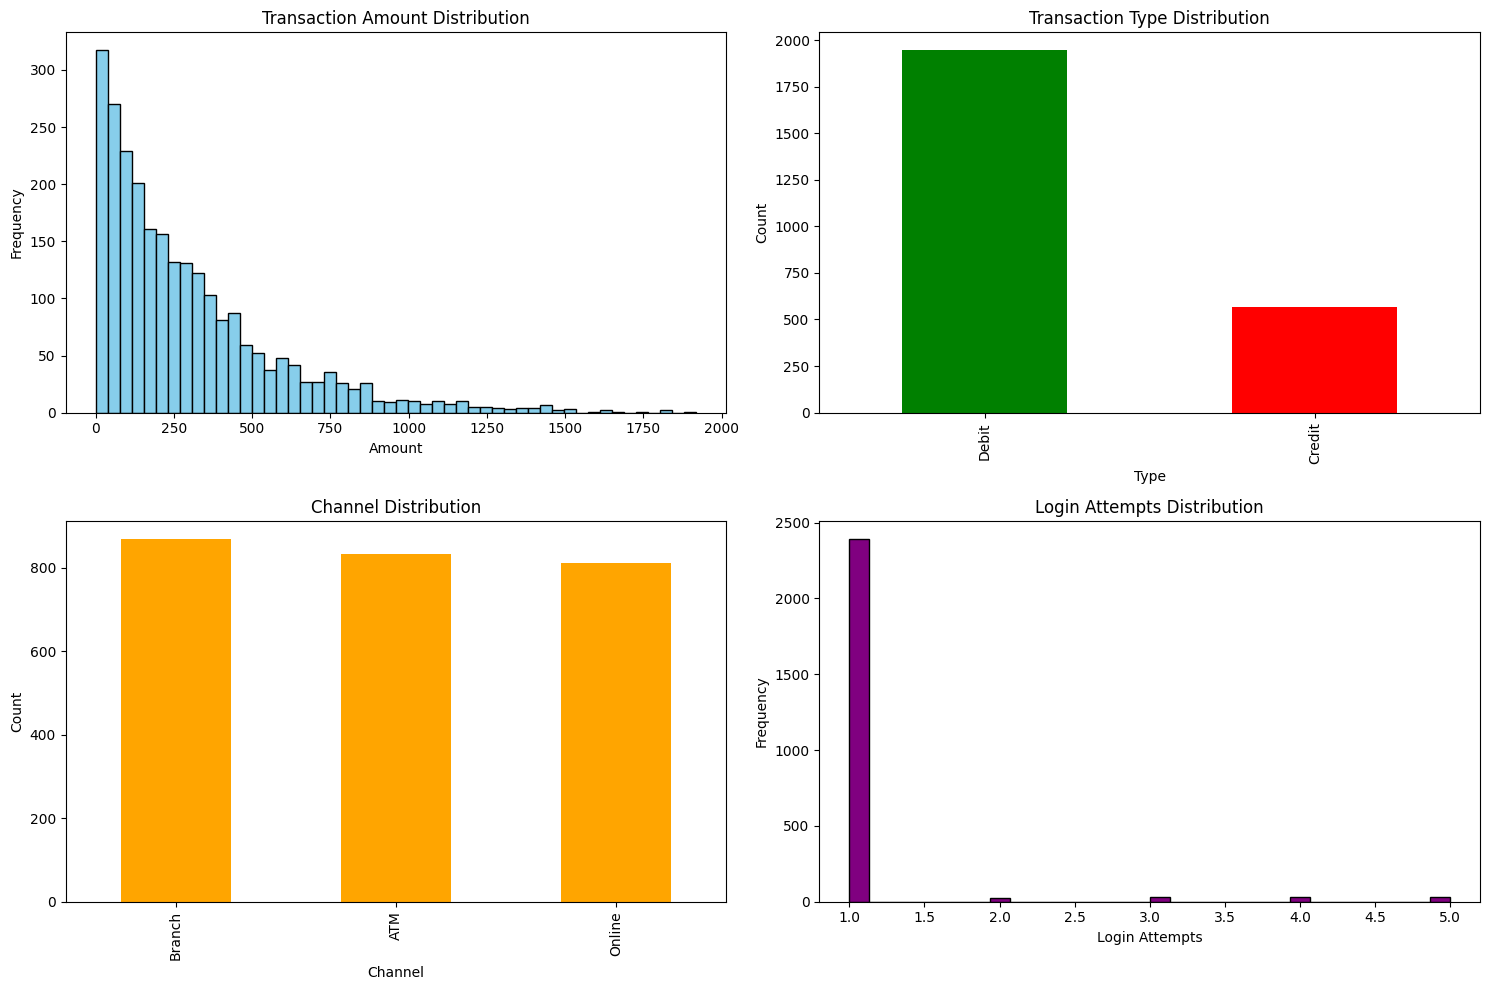

In [31]:
print("\n" + "="*80)
print("EXPLORATORY DATA ANALYSIS")
print("="*80)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Transaction Amount Distribution
axes[0, 0].hist(df['TransactionAmount'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Transaction Amount Distribution')
axes[0, 0].set_xlabel('Amount')
axes[0, 0].set_ylabel('Frequency')

# Transaction Type
df['TransactionType'].value_counts().plot(kind='bar', ax=axes[0, 1], color=['green', 'red'])
axes[0, 1].set_title('Transaction Type Distribution')
axes[0, 1].set_xlabel('Type')
axes[0, 1].set_ylabel('Count')

# Channel Distribution
df['Channel'].value_counts().plot(kind='bar', ax=axes[1, 0], color='orange')
axes[1, 0].set_title('Channel Distribution')
axes[1, 0].set_xlabel('Channel')
axes[1, 0].set_ylabel('Count')

# Login Attempts Distribution
axes[1, 1].hist(df['LoginAttempts'], bins=30, color='purple', edgecolor='black')
axes[1, 1].set_title('Login Attempts Distribution')
axes[1, 1].set_xlabel('Login Attempts')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## **5. Feature Engineering**
Membuat fitur-fitur baru yang relevan untuk deteksi fraud:
- **Temporal Features**: Hour, Day, Month, Day of Week dari transaksi
- **Time_Since_Last_Transaction**: Jarak waktu antar transaksi (jam)
- **Transaction_Frequency**: Frekuensi transaksi per account
- **Balance_to_Amount_Ratio**: Rasio saldo terhadap jumlah transaksi
- **Label Encoding**: Konversi variabel kategorikal ke numerik

In [32]:
# Copy dataframe
df_processed = df.copy()

# Convert TransactionDate to datetime
df_processed['TransactionDate'] = pd.to_datetime(df_processed['TransactionDate'])
df_processed['PreviousTransactionDate'] = pd.to_datetime(df_processed['PreviousTransactionDate'])

# Extract datetime features
df_processed['Transaction_Hour'] = df_processed['TransactionDate'].dt.hour
df_processed['Transaction_Day'] = df_processed['TransactionDate'].dt.day
df_processed['Transaction_Month'] = df_processed['TransactionDate'].dt.month
df_processed['Transaction_DayOfWeek'] = df_processed['TransactionDate'].dt.dayofweek

# Time between transactions (in hours)
df_processed['Time_Since_Last_Transaction'] = (
    df_processed['TransactionDate'] - df_processed['PreviousTransactionDate']
).dt.total_seconds() / 3600

# Handle NaN in Time_Since_Last_Transaction (first transactions)
df_processed['Time_Since_Last_Transaction'].fillna(
    df_processed['Time_Since_Last_Transaction'].median(), inplace=True
)

# Transaction frequency features
df_processed['Transaction_Frequency'] = df_processed.groupby('AccountID')['TransactionID'].transform('count')

# Balance to Amount ratio
df_processed['Balance_to_Amount_Ratio'] = df_processed['AccountBalance'] / (df_processed['TransactionAmount'] + 1)

# Label Encoding for categorical variables
label_encoders = {}
categorical_columns = ['TransactionType', 'Location', 'Channel', 'CustomerOccupation']

for col in categorical_columns:
    le = LabelEncoder()
    df_processed[f'{col}_Encoded'] = le.fit_transform(df_processed[col])
    label_encoders[col] = le

# Select features for modeling
feature_columns = [
    'TransactionAmount', 'AccountBalance', 'CustomerAge', 'TransactionDuration',
    'LoginAttempts', 'Transaction_Hour', 'Transaction_Day', 'Transaction_Month',
    'Transaction_DayOfWeek', 'Time_Since_Last_Transaction', 'Transaction_Frequency',
    'Balance_to_Amount_Ratio', 'TransactionType_Encoded', 'Location_Encoded',
    'Channel_Encoded', 'CustomerOccupation_Encoded'
]

X = df_processed[feature_columns].copy()

# Handle any remaining missing values
X.fillna(X.median(), inplace=True)

print(f"Feature Matrix Shape: {X.shape}")
print(f"\nFeatures used: {feature_columns}")

Feature Matrix Shape: (2512, 16)

Features used: ['TransactionAmount', 'AccountBalance', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'Transaction_Hour', 'Transaction_Day', 'Transaction_Month', 'Transaction_DayOfWeek', 'Time_Since_Last_Transaction', 'Transaction_Frequency', 'Balance_to_Amount_Ratio', 'TransactionType_Encoded', 'Location_Encoded', 'Channel_Encoded', 'CustomerOccupation_Encoded']


## **6. Feature Scaling**
Normalisasi fitur menggunakan StandardScaler agar semua fitur memiliki skala yang sama. Penting untuk algoritma yang sensitif terhadap skala seperti Neural Networks dan K-Means.

In [33]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_columns)

print("Scaling completed!")
print(f"Scaled data shape: {X_scaled.shape}")

Scaling completed!
Scaled data shape: (2512, 16)


## **7. Clustering for Label Generation**
Karena dataset tidak memiliki label, kita gunakan **unsupervised learning** untuk generate label:
 
Method 1: K-Means Clustering
- Membagi data menjadi 2 cluster (normal vs fraud)
- Cluster dengan jumlah sampel lebih sedikit diasumsikan sebagai fraud
 
Method 2: Isolation Forest
- Algoritma khusus untuk anomaly detection
- Mendeteksi outlier sebagai kandidat fraud (contamination=10%) 
**Silhouette Score** digunakan untuk evaluasi kualitas clustering


--- K-Means Clustering ---
Silhouette Score (K-Means): 0.0949
Cluster Distribution:
1    1271
0    1241
Name: count, dtype: int64

--- Isolation Forest ---
Anomaly Distribution (Isolation Forest):
0    2260
1     252
Name: count, dtype: int64

Fraud Labels from K-Means:
0    1271
1    1241
Name: count, dtype: int64


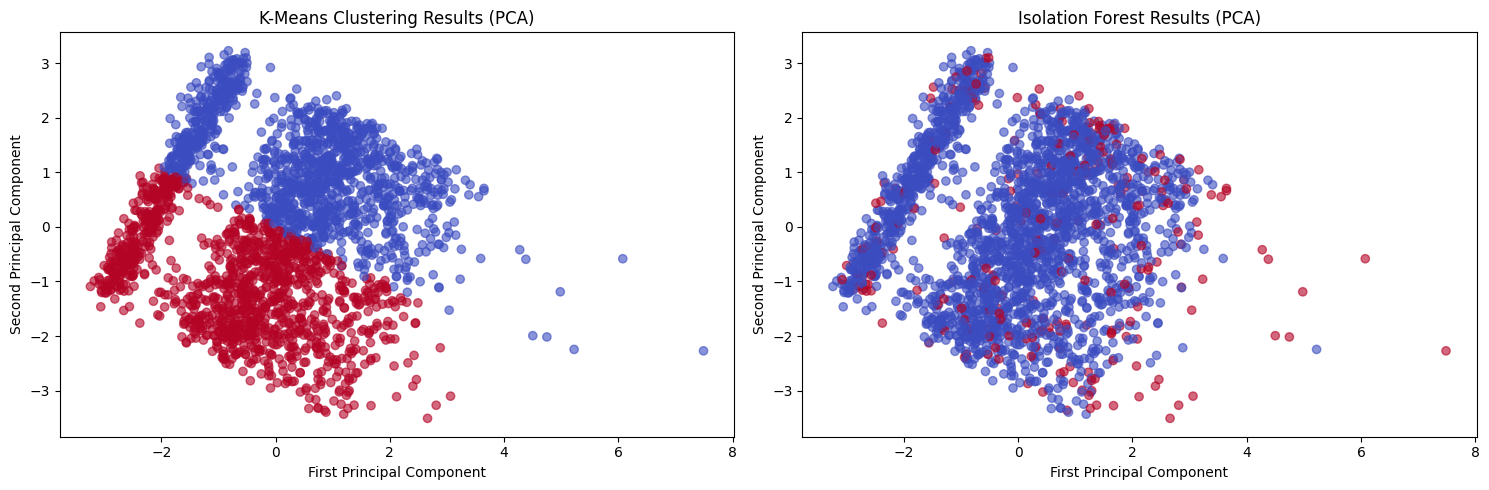

In [34]:
# Method 1: K-Means Clustering
print("\n--- K-Means Clustering ---")
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

silhouette_kmeans = silhouette_score(X_scaled, kmeans_labels)
print(f"Silhouette Score (K-Means): {silhouette_kmeans:.4f}")
print(f"Cluster Distribution:")
print(pd.Series(kmeans_labels).value_counts())

# Method 2: Isolation Forest (for anomaly detection)
print("\n--- Isolation Forest ---")
iso_forest = IsolationForest(contamination=0.1, random_state=42)
iso_labels = iso_forest.fit_predict(X_scaled)
# Convert to binary: -1 (anomaly) → 1 (fraud), 1 (normal) → 0 (normal)
iso_labels = np.where(iso_labels == -1, 1, 0)

print(f"Anomaly Distribution (Isolation Forest):")
print(pd.Series(iso_labels).value_counts())

# Assume smaller cluster from K-Means is fraud (anomaly)
# Count samples in each cluster
cluster_counts = pd.Series(kmeans_labels).value_counts()
fraud_cluster = cluster_counts.idxmin()  # Cluster with fewer samples

# Create labels: fraud cluster = 1, normal cluster = 0
y_kmeans = np.where(kmeans_labels == fraud_cluster, 1, 0)

print(f"\nFraud Labels from K-Means:")
print(pd.Series(y_kmeans).value_counts())

# We'll use K-Means labels as our primary labels
y = y_kmeans

# Visualize clustering results
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# K-Means visualization (using first 2 principal components for visualization)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, cmap='coolwarm', alpha=0.6)
axes[0].set_title('K-Means Clustering Results (PCA)')
axes[0].set_xlabel('First Principal Component')
axes[0].set_ylabel('Second Principal Component')

# Isolation Forest visualization
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=iso_labels, cmap='coolwarm', alpha=0.6)
axes[1].set_title('Isolation Forest Results (PCA)')
axes[1].set_xlabel('First Principal Component')
axes[1].set_ylabel('Second Principal Component')

plt.tight_layout()
plt.show()

## **8. Split Data**
Membagi data menjadi 3 bagian dengan stratified sampling (mempertahankan proporsi kelas):
- **Training Set (70%)**: Untuk melatih model
- **Validation Set (15%)**: Untuk evaluasi performa selama development
- **Test Set (15%)**: Untuk evaluasi final yang objektif

In [35]:
# Split: 70% train, 15% validation, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp  # 0.176 * 0.85 ≈ 0.15
)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nClass distribution in training set:")
print(pd.Series(y_train).value_counts())

Training set: (1759, 16)
Validation set: (376, 16)
Test set: (377, 16)

Class distribution in training set:
0    890
1    869
Name: count, dtype: int64


## **9. Machine Learning Models**

### **9.1 Model 1: Random Forest Classifier**
- Ensemble learning method menggunakan multiple decision trees
- Robust terhadap overfitting dan dapat handle non-linear relationships
- Memberikan feature importance untuk interpretability

In [36]:
ml_results = {}

# --- MODEL 1: RANDOM FOREST ---
print("\n--- Random Forest Classifier ---")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Validation
y_val_pred_rf = rf_model.predict(X_val)
val_acc_rf = accuracy_score(y_val, y_val_pred_rf)
print(f"Validation Accuracy: {val_acc_rf:.4f}")

# Cross-validation
cv_scores_rf = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"Cross-Validation Scores: {cv_scores_rf}")
print(f"Mean CV Accuracy: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})")

# Test
y_test_pred_rf = rf_model.predict(X_test)
test_acc_rf = accuracy_score(y_test, y_test_pred_rf)
print(f"Test Accuracy: {test_acc_rf:.4f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_rf))

ml_results['Random Forest'] = {
    'model': rf_model,
    'val_accuracy': val_acc_rf,
    'test_accuracy': test_acc_rf,
    'cv_scores': cv_scores_rf,
    'predictions': y_test_pred_rf
}


--- Random Forest Classifier ---
Validation Accuracy: 0.9973
Cross-Validation Scores: [0.99715909 0.98863636 0.99147727 0.98295455 0.98575499]
Mean CV Accuracy: 0.9892 (+/- 0.0049)
Test Accuracy: 0.9920

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       191
           1       0.98      1.00      0.99       186

    accuracy                           0.99       377
   macro avg       0.99      0.99      0.99       377
weighted avg       0.99      0.99      0.99       377



### **9.2 Model 2: Logistic Regression**
- Model linear sederhana namun efektif untuk binary classification
- Fast training dan inference
- Good baseline model untuk comparison 
**Evaluation**: Validation accuracy, 5-Fold Cross-Validation, dan Test accuracy

In [37]:
print("\n--- Logistic Regression ---")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Validation
y_val_pred_lr = lr_model.predict(X_val)
val_acc_lr = accuracy_score(y_val, y_val_pred_lr)
print(f"Validation Accuracy: {val_acc_lr:.4f}")

# Cross-validation
cv_scores_lr = cross_val_score(lr_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"Cross-Validation Scores: {cv_scores_lr}")
print(f"Mean CV Accuracy: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std():.4f})")

# Test
y_test_pred_lr = lr_model.predict(X_test)
test_acc_lr = accuracy_score(y_test, y_test_pred_lr)
print(f"Test Accuracy: {test_acc_lr:.4f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_lr))

ml_results['Logistic Regression'] = {
    'model': lr_model,
    'val_accuracy': val_acc_lr,
    'test_accuracy': test_acc_lr,
    'cv_scores': cv_scores_lr,
    'predictions': y_test_pred_lr
}


--- Logistic Regression ---
Validation Accuracy: 1.0000
Cross-Validation Scores: [1.         0.98579545 1.         0.99431818 0.99430199]
Mean CV Accuracy: 0.9949 (+/- 0.0052)
Test Accuracy: 0.9920

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       191
           1       0.99      0.99      0.99       186

    accuracy                           0.99       377
   macro avg       0.99      0.99      0.99       377
weighted avg       0.99      0.99      0.99       377



## **10. Deep Learning Models**

### **10.1 Model 3: Feedforward Neural Network (ANN)**
- **Architecture**: 4 hidden layers (128→64→32→16 neurons)
- **Regularization**: Batch Normalization + Dropout untuk prevent overfitting
- **Activation**: ReLU untuk hidden layers, Sigmoid untuk output layer
- **Training**: Early stopping dengan patience=10 untuk optimal training


--- Feedforward Neural Network (ANN) ---
Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_27 (Dense)            (None, 128)               2176      
                                                                 
 batch_normalization_17 (Bat  (None, 128)              512       
 chNormalization)                                                
                                                                 
 dropout_19 (Dropout)        (None, 128)               0         
                                                                 
 dense_28 (Dense)            (None, 64)                8256      
                                                                 
 batch_normalization_18 (Bat  (None, 64)               256       
 chNormalization)                                                
                                                                 
 dropout_20 

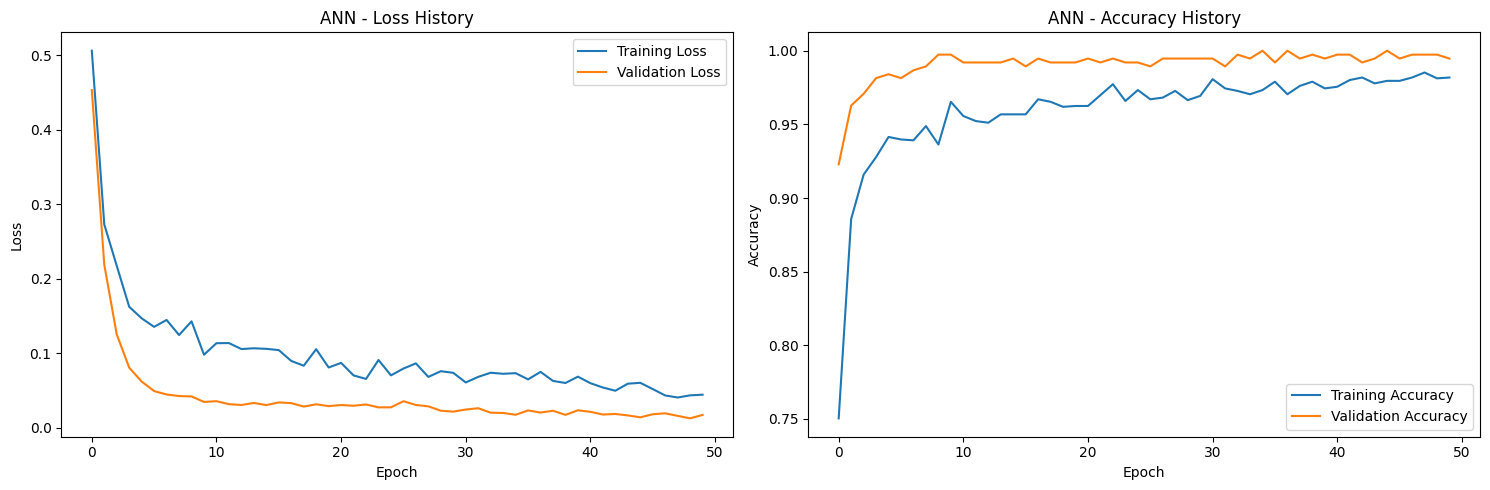

In [ ]:
dl_results = {}

# Convert to numpy arrays for DL
X_train_np = X_train.values
X_val_np = X_val.values
X_test_np = X_test.values

# --- MODEL 3: FEEDFORWARD NEURAL NETWORK (ANN) ---
print("\n--- Feedforward Neural Network (ANN) ---")

# Build model
ann_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_np.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(16, activation='relu'),
    
    Dense(1, activation='sigmoid')
])

ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(ann_model.summary())

# Train model
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_ann = ann_model.fit(
    X_train_np, y_train,
    validation_data=(X_val_np, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# Evaluate on validation set
val_loss_ann, val_acc_ann = ann_model.evaluate(X_val_np, y_val, verbose=0)
print(f"\nValidation Accuracy: {val_acc_ann:.4f}")

# Evaluate on test set
test_loss_ann, test_acc_ann = ann_model.evaluate(X_test_np, y_test, verbose=0)
print(f"Test Accuracy: {test_acc_ann:.4f}")

# Predictions
y_test_pred_ann_proba = ann_model.predict(X_test_np)
y_test_pred_ann = (y_test_pred_ann_proba > 0.5).astype(int).flatten()

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_ann))

dl_results['ANN'] = {
    'model': ann_model,
    'history': history_ann,
    'val_accuracy': val_acc_ann,
    'test_accuracy': test_acc_ann,
    'predictions': y_test_pred_ann
}

# ### 📊 ANN Training History Visualization
# Visualisasi learning curves untuk memantau training process dan detect overfitting

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history_ann.history['loss'], label='Training Loss')
axes[0].plot(history_ann.history['val_loss'], label='Validation Loss')
axes[0].set_title('ANN - Loss History')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_ann.history['accuracy'], label='Training Accuracy')
axes[1].plot(history_ann.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('ANN - Accuracy History')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()


### **10.2 Model 4: Deep Neural Network (DNN)**
- **Architecture**: 5 hidden layers (256→128→64→32→16 neurons)
- **Deeper network** untuk capture complex patterns
- **Higher dropout rates** pada layer awal untuk regularization
 
**Optimizer**: Adam | **Loss**: Binary Cross-Entropy | **Metrics**: Accuracy


--- Deep Neural Network (DNN) ---
Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_32 (Dense)            (None, 256)               4352      
                                                                 
 batch_normalization_20 (Bat  (None, 256)              1024      
 chNormalization)                                                
                                                                 
 dropout_22 (Dropout)        (None, 256)               0         
                                                                 
 dense_33 (Dense)            (None, 128)               32896     
                                                                 
 batch_normalization_21 (Bat  (None, 128)              512       
 chNormalization)                                                
                                                                 
 dropout_23 (Dropou

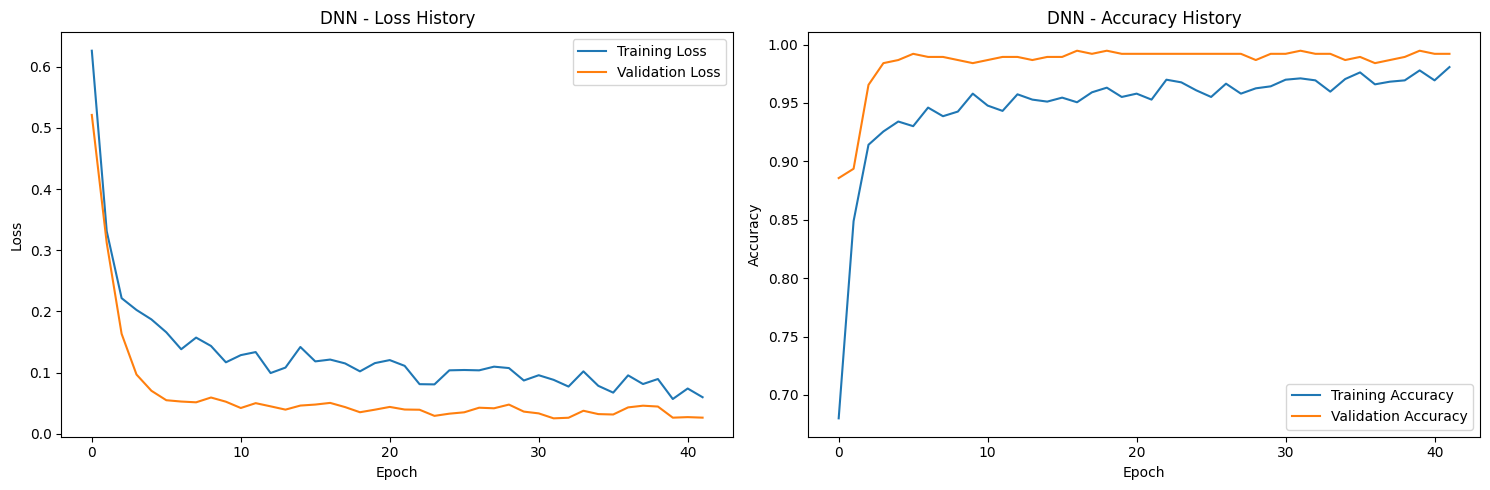

In [39]:
print("\n--- Deep Neural Network (DNN) ---")

# Build deeper model
dnn_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_np.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(16, activation='relu'),
    Dropout(0.2),
    
    Dense(1, activation='sigmoid')
])

dnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(dnn_model.summary())

# Train model
history_dnn = dnn_model.fit(
    X_train_np, y_train,
    validation_data=(X_val_np, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# Evaluate on validation set
val_loss_dnn, val_acc_dnn = dnn_model.evaluate(X_val_np, y_val, verbose=0)
print(f"\nValidation Accuracy: {val_acc_dnn:.4f}")

# Evaluate on test set
test_loss_dnn, test_acc_dnn = dnn_model.evaluate(X_test_np, y_test, verbose=0)
print(f"Test Accuracy: {test_acc_dnn:.4f}")

# Predictions
y_test_pred_dnn_proba = dnn_model.predict(X_test_np)
y_test_pred_dnn = (y_test_pred_dnn_proba > 0.5).astype(int).flatten()

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_dnn))

dl_results['DNN'] = {
    'model': dnn_model,
    'history': history_dnn,
    'val_accuracy': val_acc_dnn,
    'test_accuracy': test_acc_dnn,
    'predictions': y_test_pred_dnn
}

# ### 📊 DNN Training History Visualization

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history_dnn.history['loss'], label='Training Loss')
axes[0].plot(history_dnn.history['val_loss'], label='Validation Loss')
axes[0].set_title('DNN - Loss History')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_dnn.history['accuracy'], label='Training Accuracy')
axes[1].plot(history_dnn.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('DNN - Accuracy History')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

## **11. Model Comparison**
Membandingkan performa keempat model berdasarkan:
- **Validation Accuracy**: Performa pada validation set
- **Test Accuracy**: Performa pada test set (unseen data)
 
Visualisasi side-by-side untuk easy comparison

                 Model  Validation Accuracy  Test Accuracy
0        Random Forest             0.997340       0.992042
1  Logistic Regression             1.000000       0.992042
2                  ANN             0.994681       0.976127
3                  DNN             0.994681       0.984085


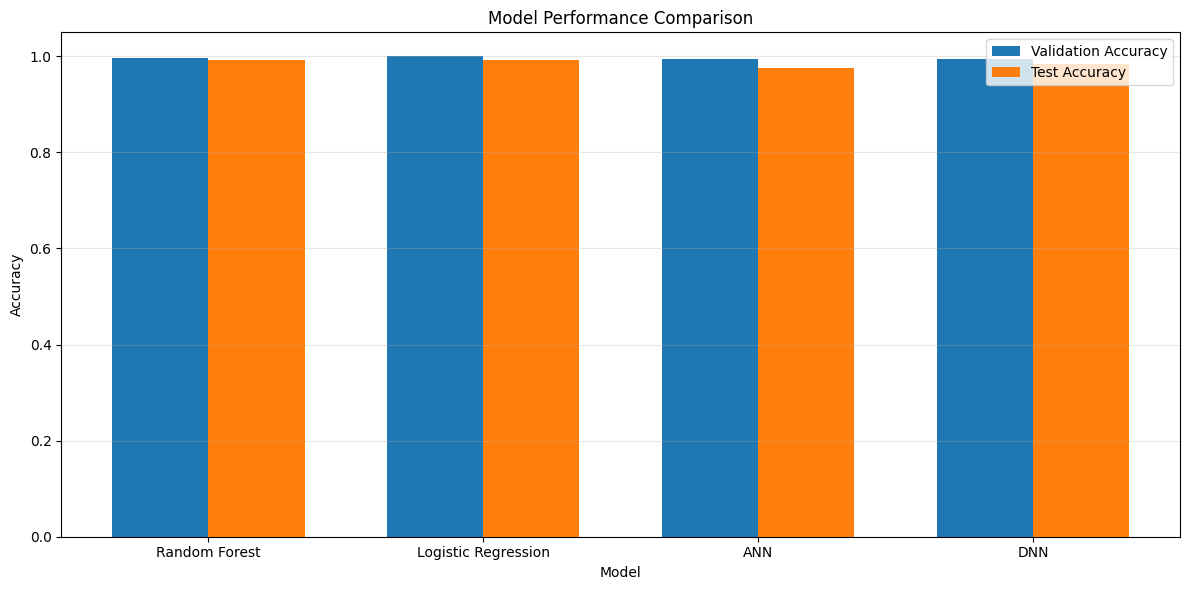

In [40]:
# Compile results
comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression', 'ANN', 'DNN'],
    'Validation Accuracy': [
        ml_results['Random Forest']['val_accuracy'],
        ml_results['Logistic Regression']['val_accuracy'],
        dl_results['ANN']['val_accuracy'],
        dl_results['DNN']['val_accuracy']
    ],
    'Test Accuracy': [
        ml_results['Random Forest']['test_accuracy'],
        ml_results['Logistic Regression']['test_accuracy'],
        dl_results['ANN']['test_accuracy'],
        dl_results['DNN']['test_accuracy']
    ]
})

print(comparison_df)

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['Validation Accuracy'], width, label='Validation Accuracy')
bars2 = ax.bar(x + width/2, comparison_df['Test Accuracy'], width, label='Test Accuracy')

ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## **12. Model Evaluation**
Confusion matrix untuk setiap model menunjukkan:
- **True Positives (TP)**: Fraud yang terdeteksi dengan benar
- **True Negatives (TN)**: Normal yang terdeteksi dengan benar
- **False Positives (FP)**: Normal yang salah diprediksi sebagai fraud
- **False Negatives (FN)**: Fraud yang tidak terdeteksi (berbahaya!)

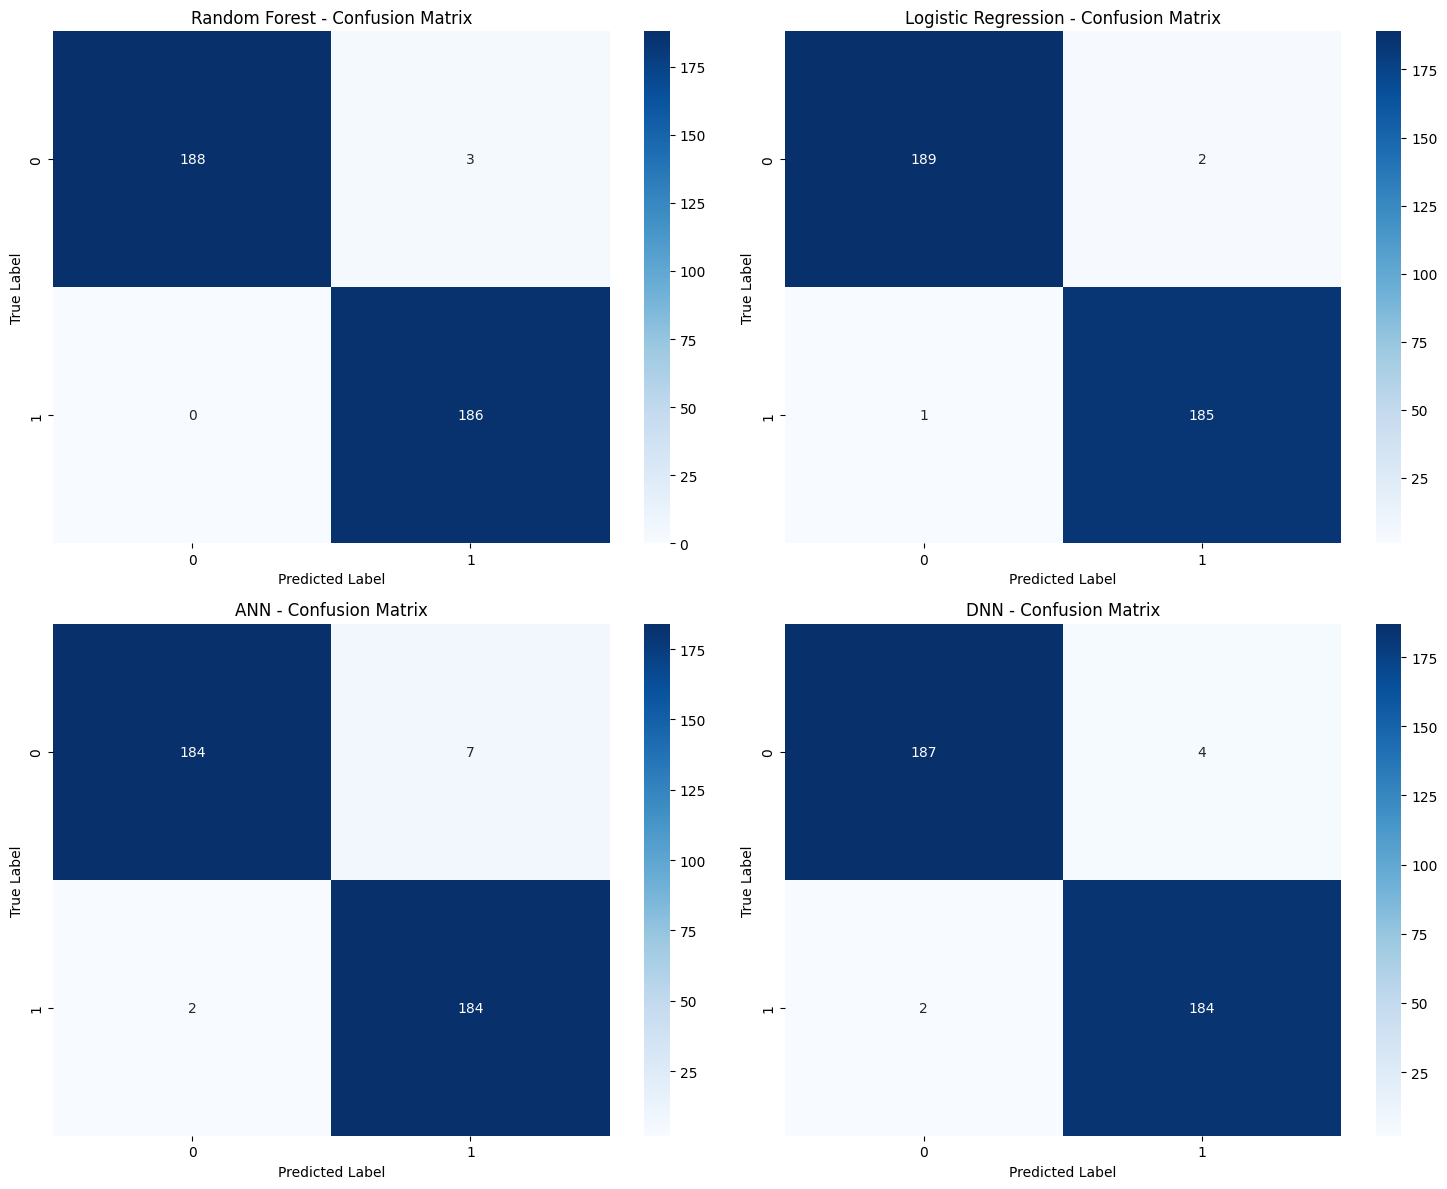

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

models_predictions = [
    ('Random Forest', y_test_pred_rf),
    ('Logistic Regression', y_test_pred_lr),
    ('ANN', y_test_pred_ann),
    ('DNN', y_test_pred_dnn)
]

for idx, (name, predictions) in enumerate(models_predictions):
    row = idx // 2
    col = idx % 2
    
    cm = confusion_matrix(y_test, predictions)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[row, col])
    axes[row, col].set_title(f'{name} - Confusion Matrix')
    axes[row, col].set_ylabel('True Label')
    axes[row, col].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

## **13. Final Summary & Feature Importance**
📊 Summary Metrics
 Ringkasan lengkap performa semua model dengan validation, cross-validation, dan test accuracy
 
🎯 Feature Importance (Random Forest)
Menampilkan 10 fitur paling penting dalam mendeteksi fraud berdasarkan Random Forest.
Fitur dengan importance tinggi adalah kandidat kuat untuk fraud indicator.


FINAL SUMMARY

--- Machine Learning Models ---

Random Forest:
  Validation Accuracy: 0.9973
  Test Accuracy: 0.9920
  Mean CV Accuracy: 0.9892

Logistic Regression:
  Validation Accuracy: 1.0000
  Test Accuracy: 0.9920
  Mean CV Accuracy: 0.9949

--- Deep Learning Models ---

ANN:
  Validation Accuracy: 0.9947
  Test Accuracy: 0.9761

DNN:
  Validation Accuracy: 0.9947
  Test Accuracy: 0.9841

ANALYSIS COMPLETE!

--- Top 10 Important Features (Random Forest) ---
                        Feature  Importance
9   Time_Since_Last_Transaction    0.498524
7             Transaction_Month    0.455395
6               Transaction_Day    0.007695
0             TransactionAmount    0.006684
11      Balance_to_Amount_Ratio    0.005557
1                AccountBalance    0.004857
3           TransactionDuration    0.004063
2                   CustomerAge    0.003445
10        Transaction_Frequency    0.003419
13             Location_Encoded    0.003211


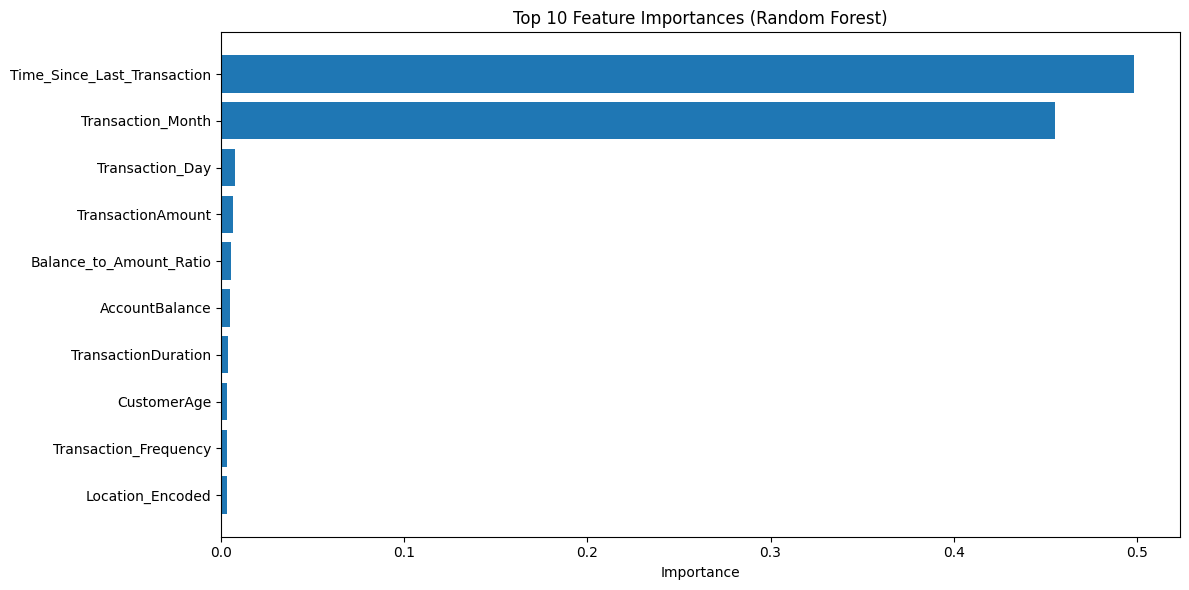

In [42]:
print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)

print("\n--- Machine Learning Models ---")
for model_name, results in ml_results.items():
    print(f"\n{model_name}:")
    print(f"  Validation Accuracy: {results['val_accuracy']:.4f}")
    print(f"  Test Accuracy: {results['test_accuracy']:.4f}")
    print(f"  Mean CV Accuracy: {results['cv_scores'].mean():.4f}")
    
print("\n--- Deep Learning Models ---")
for model_name, results in dl_results.items():
    print(f"\n{model_name}:")
    print(f"  Validation Accuracy: {results['val_accuracy']:.4f}")
    print(f"  Test Accuracy: {results['test_accuracy']:.4f}")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)

# Feature Importance (Random Forest)
print("\n--- Top 10 Important Features (Random Forest) ---")
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.head(10))

# Visualize feature importance
plt.figure(figsize=(12, 6))
plt.barh(feature_importance.head(10)['Feature'], feature_importance.head(10)['Importance'])
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()